<a href="https://colab.research.google.com/github/ap-vp/wrangling_assignment/blob/main/Patnaik_wrangling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling
### `! git clone https://github.com/ds3001f25/wrangling_assignment.git`
### Do Q1 and Q2
### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?
3. Dummy variable: For the pretrial data covered in the lecture `./data/justice_data.parquet`, clean the `WhetherDefendantWasReleasedPretrial` variable as well as you can, and, in particular, replace missing values with `np.nan`.
4. Missing values, not at random: For the pretrial data covered in the lecture, clean the `ImposedSentenceAllChargeInContactEvent` variable as well as you can, and explain the choices you make. (Hint: Look at the `SentenceTypeAllChargesAtConvictionInContactEvent` variable.)

**Question 1 Part 1**

In [ ]:
import numpy as np
import pandas as pd
airbnb = pd.read_csv("./airbnb_hw.csv")
print("airbnb.dtypes before:")
print(airbnb.dtypes, '\n') #see that Price is object - want to change it to int64

airbnb['Price'] = pd.to_numeric(airbnb['Price'].str.replace(',', '')) #change to int64 and remove commas
print("airbnb.dtypes after:")
print(airbnb.dtypes, '\n')

airbnb['Price'].describe() #see the data distribution - values greater than 999 present
#unsure why dtype is described as float

airbnb.dtypes before:
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object 

airbnb.dtypes after:
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                        

,Price
count,30478.000000
mean,163.589737
std,197.785454
min,10.000000
25%,80.000000
50%,125.000000
75%,195.000000
max,10000.000000


**Question 1 Part 2**

In [ ]:
import pandas as pd
minn = pd.read_csv("./mn_police_use_of_force.csv") #how to read files


print("minn.dtypes :")
print(minn.dtypes, '\n') #subject_injury is an object


print("minn.shape", minn.shape, '\n') #see that there are 12925 rows

print(minn['subject_injury'].value_counts(), '\n') #see that many values are NaN in subject_injury column
print('Percent cases Null =', ((12925 - (1631+1446))/12925)*100,"%", '\n') #76% of subject_injury are null

minn['subj_injury_nan'] = minn['subject_injury'].isnull() #create a column that highlights null subject_injury
minn_noinjury = minn[minn['subj_injury_nan']==1] #filter only the null subject_injury data sets
print("force types for null subject injury")
print(minn_noinjury['force_type'].unique(), '\n')

print("force types total")

print(minn['force_type'].unique(), '\n') #Firearm and Less Lethal Projectile appear when subject_injury is NOT null

print("force types for subject injury") #when subject injury = Yes
print(minn[minn['subject_injury']=='Yes']['force_type'].unique(), '\n')

#unsure of the patterns present when subject_injury = null

minn.dtypes :
response_datetime     object
problem               object
is_911_call           object
primary_offense       object
subject_injury        object
force_type            object
force_type_action     object
race                  object
sex                   object
age                  float64
type_resistance       object
precinct               int64
neighborhood          object
dtype: object 

minn.shape (12925, 13) 

subject_injury
Yes    1631
No     1446
Name: count, dtype: int64 

Percent cases Null = 76.19342359767892 % 

force types for null subject injury
['Bodily Force' 'Chemical Irritant' 'Gun Point Display' 'Taser'
 'Improvised Weapon' 'Maximal Restraint Technique' 'Police K9 Bite'
 'Less Lethal' 'Baton'] 

force types total
['Bodily Force' 'Chemical Irritant' 'Taser' 'Improvised Weapon'
 'Gun Point Display' 'Police K9 Bite' 'Baton' 'Firearm'
 'Less Lethal Projectile' 'Maximal Restraint Technique' 'Less Lethal'] 

force types for subject injury
['Bodily Force' 'Taser

**Question 1 Part 3**

Dummy variable: For the pretrial data covered in the lecture ./data/justice_data.parquet, clean the WhetherDefendantWasReleasedPretrial variable as well as you can, and, in particular, replace missing values with np.nan.

In [ ]:
import pandas as pd
import numpy as np
justice = pd.read_parquet("./justice_data.parquet") #how to read files
justice['WhetherDefendantWasReleasedPretrial'].head() #initial view of table
print(justice['WhetherDefendantWasReleasedPretrial'].value_counts(), '\n') #instances of possible values in table

justice.replace({'WhetherDefendantWasReleasedPretrial': 9}, np.nan, inplace=True) #replacing 9 values with np.nan

print(justice['WhetherDefendantWasReleasedPretrial'].value_counts())



WhetherDefendantWasReleasedPretrial
1    19154
0     3801
9       31
Name: count, dtype: int64 

WhetherDefendantWasReleasedPretrial
1.0    19154
0.0     3801
Name: count, dtype: int64


Missing values, not at random: For the pretrial data covered in the lecture, clean the ImposedSentenceAllChargeInContactEvent variable as well as you can, and explain the choices you make. (Hint: Look at the SentenceTypeAllChargesAtConvictionInContactEvent variable.)

**Question 1 Part 4**

In [ ]:
import pandas as pd
import numpy as np
justice = pd.read_parquet("./justice_data.parquet") #how to read files
justice[['ImposedSentenceAllChargeInContactEvent',
         'SentenceTypeAllChargesAtConvictionInContactEvent']].head(25)
#Changing null values to NaN when second column value is equal to 9 or 4
justice.loc[(justice['SentenceTypeAllChargesAtConvictionInContactEvent'].isin([9, 4]))
        & (justice['ImposedSentenceAllChargeInContactEvent'].isnull()),
            'ImposedSentenceAllChargeInContactEvent'] = np.nan

#coercing all values to either be floats or NaN, getting rid improper formatting
justice['ImposedSentenceAllChargeInContactEvent'] = pd.to_numeric(
    justice['ImposedSentenceAllChargeInContactEvent'], errors='coerce')

justice[['ImposedSentenceAllChargeInContactEvent',
         'SentenceTypeAllChargesAtConvictionInContactEvent']].head(25)


,ImposedSentenceAllChargeInContactEvent,SentenceTypeAllChargesAtConvictionInContactEvent
0,NaN,9
1,60.000000,0
2,12.000000,1
3,0.985626,1
4,NaN,4
5,12.000000,0
6,36.000000,1
7,6.000000,0
8,24.000000,1
9,12.000000,1


**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Are sharks more likely to launch unprovoked attacks on men or women? Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Is it more or less likely to be fatal when the victim is male or female? How do you feel about sharks?
9. What proportion of attacks appear to be by white sharks? (Hint: `str.split()` makes a vector of text values into a list of lists, split by spaces.)

In [104]:
#Q2P1
import pandas as pd
import numpy as np
shark = pd.read_excel("./GSAF5.xls")

#Q2P2
shark.dropna(axis=1, how='all', inplace=True) #dropped all columns with ONLY NaN
shark.head()


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,16th August 2025,2025.0,Provoked,USA,Florida,Cayo Costa Boca Grande,Fishing,Shawn Meuse,M,?,...,Lemon shark 1.8 m (6ft),Johannes Marchand: Kevin McMurray Trackingshar...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18th August,2025.0,Unprovoked,Australia,NSW,Cabarita Beach,Surfing,Brad Ross,M,?,...,5m (16.5ft) Great White,Bob Myatt GSAF The Guardian: 9 News: ABS News:...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17th August,2025.0,Unprovoked,Bahamas,Atlantic Ocean near Big Grand Cay,North of Grand Bahama near Freeport,Spearfishing,Not stated,M,63,...,Undetermined,Ralph Collier GSAF and Kevin MCMurray Tracking...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7th August,2025.0,Unprovoked,Australia,NSW,Tathra Beach,Surfing,Bowie Daley,M,9,...,Suspected Great White,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1st August,2025.0,Unprovoked,Puerto Rico,Carolina,Carolina Beach,Wading,Eleonora Boi,F,39,...,Undetermined,Kevin McMurray Trackingsharks.com: NY Post,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [105]:

#Q2P3
shark['Year'] = pd.to_numeric(
    shark['Year'], errors='coerce')
shark['Year'].unique()
#the range of values goes from 0-2026 with most values falling between 1500 and 2026

shark1940 = shark[shark['Year'] >= 1940] #filtered to only have years 1940 and later
shark1940sorterd = shark1940.sort_values(by='Year') #sort values by year to show progression
shark1940sorterd['Year'].value_counts() #attacks are increasing over time




,count
Year,
2015.0,143
2017.0,141
2016.0,133
2011.0,128
2014.0,126
...,...
1978.0,26
1979.0,25
1940.0,24


<Axes: >

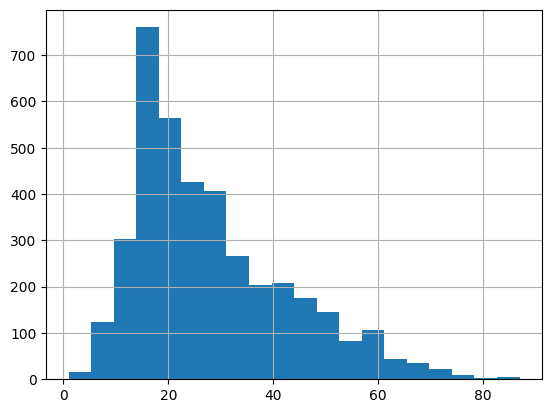

In [106]:

#Q2P4
shark['Age'] = pd.to_numeric(shark['Age'], errors='coerce') #clean data

shark['Age'].unique()
shark['Age'].hist(bins=20) #create histogram with bins of every 5 years




In [114]:
#Q2P5
print(shark['Sex'].shape, '\n')
print(shark['Sex'].value_counts(), '\n')
print("total percent of male victims", shark['Sex'].value_counts(normalize=True)['M']) #percent of victims that were male


(7042,) 

Sex
M        5647
F         804
M           3
F           2
N           2
 M          1
m           1
lli         1
M x 2       1
.           1
Name: count, dtype: int64 

total percent of male victims 0.8737428438805508


In [121]:
#Q2P6
shark['Type'].value_counts()

shark.loc[~shark['Type'].isin(["Unprovoked", "Provoked",]) & shark['Type'].notna(), 'Type'] = "Unknown"
#lists all values not Provoked or Unprovoked as Unknown

shark['Type'].value_counts()


,count
Type,
Unprovoked,5196
Unknown,1189
Provoked,639



*What* proportion of attacks appear to be by white sharks? (Hint: str.split() makes a vector of text values into a list of lists, split by spaces.)

In [130]:
#Q2P7
shark['Fatal Y/N'].value_counts()

shark.loc[~shark['Fatal Y/N'].isin(["Y", "N",]) & shark['Fatal Y/N'].notna(), 'Fatal Y/N'] = "Unknown"
#lists all values not Y/N as Unknown

shark['Fatal Y/N'].value_counts()

,count
Fatal Y/N,
N,4908
Y,1481
Unknown,92


In [137]:
#Q2P8
shark.loc[~shark['Sex'].isin(["F", "M",]) & shark['Sex'].notna(), 'Sex'] = "Unknown"

print(shark.loc[shark['Type'].isin(["Unprovoked"]), 'Sex'].value_counts(), '\n')#prints Unprovoked attacks based on sex
#more likely for sharks to attack men


print(shark.loc[shark['Fatal Y/N'].isin(["Y"]), 'Type'].value_counts(), '\n') #print fatal attacks based on type
# more likely for unprovoked attacks to be fatal


print(shark.loc[shark['Fatal Y/N'].isin(["Y"]), 'Sex'].value_counts(), '\n') #print fatal attacks based on sex
#more likely for men to be fatally attacked

#I do not like sharks!




Sex
M          4340
F           681
Unknown       7
Name: count, dtype: int64 

Type
Unprovoked    1260
Unknown        197
Provoked        20
Name: count, dtype: int64 

Sex
M          1249
F           122
Unknown       3
Name: count, dtype: int64 



In [149]:
#Q2P9
# print(shark.columns) # Print column names to check

#column Species had an extra space
print("Proportion of attacks by white sharks:")
print(shark['Species '].str.contains('white', case=False, na=False).mean())

Proportion of attacks by white sharks:
0.10678784436239705
